# **Orbita Digital - EDA Ventas**

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Load Data**

In [54]:
wb = pd.ExcelFile("../data/raw/Ventas_OrbitaDigital.xlsx")
wb.sheet_names

['Hoja1']

In [55]:
df_ventas = pd.read_excel("../data/raw/Ventas_OrbitaDigital.xlsx", sheet_name="Hoja1")
df_ventas.head()

,Fecha De Venta,Ubicación,Producto,Marca,Categoría,Precio Unidad,Costo Unidad,Cantidad Vendida,Facturación
0,2020-06-01,"Brasil, América del Sur",Juego Mesa for kids E300 Prata,Kid Toys,Juegos de mesa,5.5,2.8,1.0,5.5
1,2020-06-01,"Estados Unidos, América del Norte",Juego Mesa for kids E300 Prata,Kid Toys,Juegos de mesa,5.5,2.8,1.0,5.5
2,2020-06-01,"Eslovenia, Europa",Juego Mesa for kids E300 Prata,Kid Toys,Juegos de mesa,5.5,2.8,2.0,11.0
3,2020-06-01,"Canadá, América del Norte",Juego Mesa for kids E300 Prata,Kid Toys,Juegos de mesa,5.5,2.8,1.0,5.5
4,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Data Overview**

This section provides a general summary of dataset before performing other sections such as data quality assesment, exploratory data visualization, etc.

In [57]:
overview = pd.DataFrame({
    "Metric": ["Number of records", "Number of columns", "Time period", "Categories",
               "Locations", "Products", "Brands"],
    "Values": [
        df_ventas.shape[0],
        df_ventas.shape[1],
        f"{df_ventas['Fecha De Venta'].min().strftime('%b %Y')} - {df_ventas['Fecha De Venta'].max().strftime('%b %Y')}",
        df_ventas['Categoría'].nunique(),
        df_ventas['Ubicación'].nunique(),
        df_ventas['Producto'].nunique(),
        df_ventas['Marca'].nunique(),
    ]
})

overview

,Metric,Values
0,Number of records,22419
1,Number of columns,9
2,Time period,Jun 2020 - Aug 2022
3,Categories,20
4,Locations,37
5,Products,444
6,Brands,7


#### **Data types**

In [61]:
data_types = pd.DataFrame({
    "Column": df_ventas.columns,
    "Data Type": df_ventas.dtypes.values
})

data_types

,Column,Data Type
0,Fecha De Venta,datetime64[us]
1,Ubicación,str
2,Producto,str
3,Marca,str
4,Categoría,str
5,Precio Unidad,float64
6,Costo Unidad,float64
7,Cantidad Vendida,float64
8,Facturación,float64


##### **Observations**

- The dataset contains historical information about sales transactions
- Apparently each row represents a different sale transaction, since there is not a identifier for each sale.
- The dataset has more than 22,000 records and 9 features or columns
- There are 37 different locations, but in the same column are the country and continent
- The 444 different products belong to 7 brands and 20 categories.

### **Dataset Quality Assesment**

In [63]:
overview_quality = pd.DataFrame({
    "Metric": ["Missing Values", "Duplicated"],
    "Values": [
        df_ventas.isna().sum().sum(),
        df_ventas.duplicated().sum(),
    ]
})

overview_quality

,Metric,Values
0,Missing Values,90
1,Duplicated,2759


**Where are the missing values?**

In [71]:
na_df = pd.DataFrame({
    "Column": df_ventas.columns,
    "Missing Values": df_ventas.isna().sum().values
})

na_df

,Column,Missing Values
0,Fecha De Venta,10
1,Ubicación,10
2,Producto,10
3,Marca,10
4,Categoría,10
5,Precio Unidad,10
6,Costo Unidad,10
7,Cantidad Vendida,10
8,Facturación,10


**Where is duplicated data**

In [67]:
df_ventas[df_ventas.duplicated()].head(10)

,Fecha De Venta,Ubicación,Producto,Marca,Categoría,Precio Unidad,Costo Unidad,Cantidad Vendida,Facturación
10,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,2020-06-01,"Estados Unidos, América del Norte",Age of Mythology 2009 E158,Kid Toys,Juegos,32.0,16.31,1.0,32.0
25,2020-06-01,"Estados Unidos, América del Norte",Age of Mythology 2009 E158,Kid Toys,Juegos,32.0,16.31,1.0,32.0
27,2020-06-01,"Estados Unidos, América del Norte",Juego Mesa for kids E300 Prata,Kid Toys,Juegos de mesa,5.5,2.80,1.0,5.5
28,2020-06-01,"Brasil, América del Sur",Juego Mesa for kids E300 Prata,Kid Toys,Juegos de mesa,5.5,2.80,1.0,5.5
29,2020-06-01,"Estados Unidos, América del Norte",Juego Mesa for kids E300 Prata,Kid Toys,Juegos de mesa,5.5,2.80,1.0,5.5
30,2020-06-01,"Eslovenia, Europa",Juego Mesa for kids E300 Prata,Kid Toys,Juegos de mesa,5.5,2.80,2.0,11.0
31,2020-06-01,"Canadá, América del Norte",Juego Mesa for kids E300 Prata,Kid Toys,Juegos de mesa,5.5,2.80,1.0,5.5


#### **Unique Values**

In [68]:
unique_data = pd.DataFrame({
    "Column": ["Ubicación", "Producto", "Categoría", "Marca"],
    "Unique Values": [
        df_ventas["Ubicación"].unique(),
        df_ventas["Producto"].unique(),
        df_ventas["Categoría"].unique(),
        df_ventas["Marca"].unique()
    ]
})

unique_data

,Column,Unique Values
0,Ubicación,"[Brasil, América del Sur, Estados Unidos, Amér..."
1,Producto,"[Juego Mesa for kids E300 Prata, nan, Juego Me..."
2,Categoría,"[Juegos de mesa, nan, Juegos, Auriculares Blue..."
3,Marca,"[Kid Toys, nan, Philips, Ninja, Sonos, Sony, L..."


##### **Observations**
- The dataset has 90 missing values and more tanh 2,000 duplicated data
- Each column contains 10 missing values
- Duplicated data apparently represents a single sale transaction.
- It is necessary drop missing values because entire rows have missing values, and it is not necessary drop duplicated data.
- The Ubicación column must be divided into País and Continent

### **Exploratory Data Visualization**

**Missing Values**

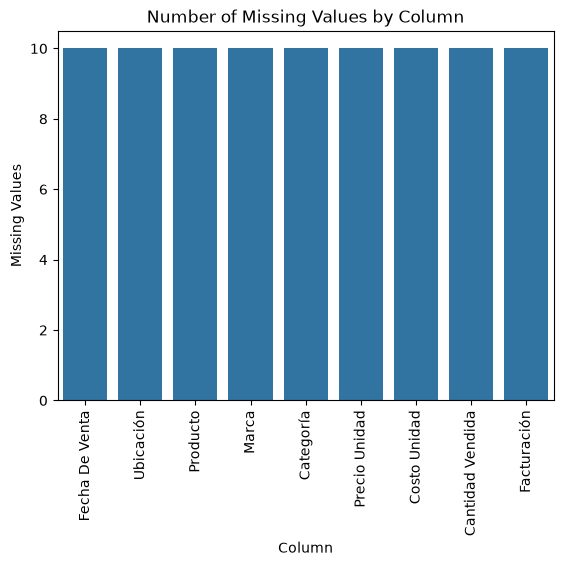

In [74]:
sns.barplot(data= na_df, x="Column", y="Missing Values")
plt.title("Number of Missing Values by Column")
plt.xticks(rotation=90)
plt.show()

**Observations:** All features have 10 missing values, like the above table in data quality assessment showed

**Number of transactions per continent**

In [85]:
df_ventas[['País', 'Continente']] = df_ventas['Ubicación'].str.split(", ", expand=True)

# drop missing values
df_ventas = df_ventas.dropna()

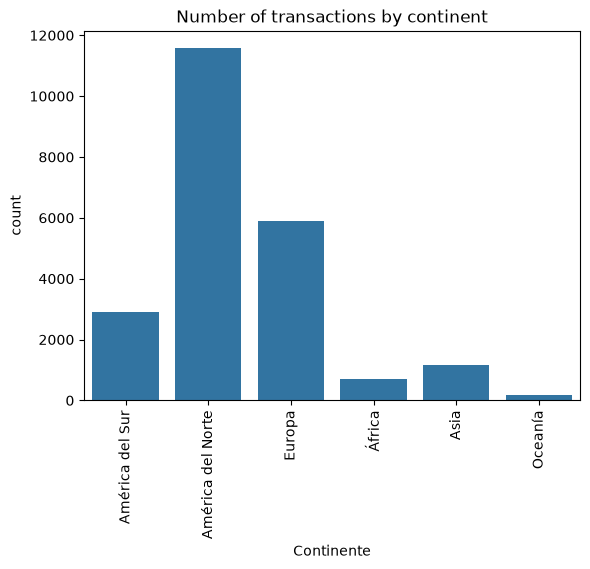

In [86]:
sns.countplot(df_ventas, x='Continente')
plt.title("Number of transactions by continent")
plt.xticks(rotation=90)
plt.show()

**Number of sale transactions by country**

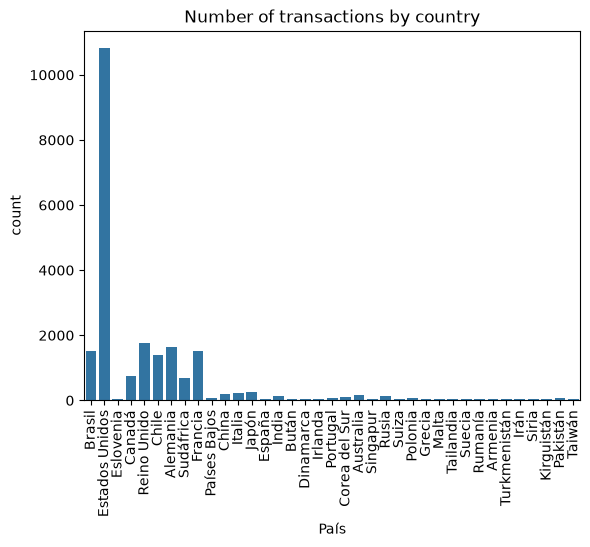

In [87]:
sns.countplot(df_ventas, x='País')
plt.title("Number of transactions by country")
plt.xticks(rotation=90)
plt.show()

**Revenue Distribution**

Text(0.5, 1.0, '')

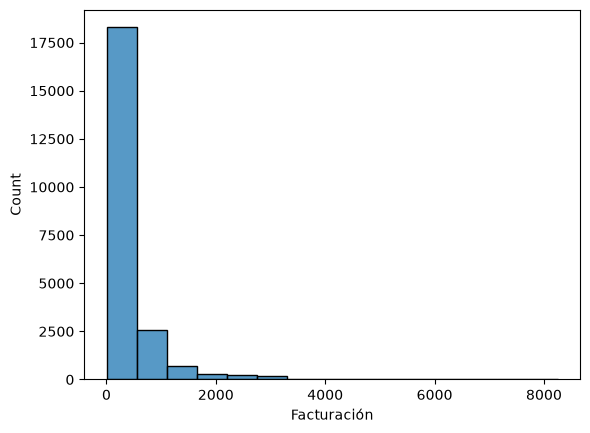

In [88]:
sns.histplot(df_ventas, x="Facturación", bins=15)
plt.title("Revenue Distribution")
plt.title("")

**Observation:** The data in Facturación is highly right-skewed, showing that the most of the transactions have low revenue values, while a small number of transactions correspond to substantially higher revenue values. This type of pattern is common in retail dataset, which indicates the presence of high-value sales that can affect some aggregate metrics.

**Sales quantity Distribution**

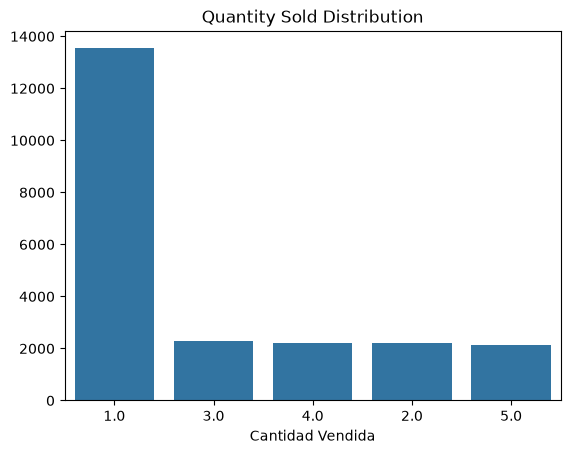

In [100]:
quantity_sold = df_ventas["Cantidad Vendida"].value_counts()
sns.barplot(x=quantity_sold.index.astype("str"),
            y=quantity_sold.values)
plt.title("Quantity Sold Distribution")
plt.show()

**Observation:** The "Cantidad Vendida" feature is a discrete variable ranging between 1 and 5 units per transaction. Most transactions involve the purchase of only 1 unit, while transactions with more units sold occur less frequently. this can indicate that the bussines handles low-volume purchases.

## **EDA Conclusions**

- The dataset contains 22,419 sales transactions across 36 countries, 7 brands, 20 product categories, and 444 unique products, providing sufficient coverage for commercial profitability analysis.
- Data quality assessment identified 10 completely empty records, which must be removed from the dataset. No significant issues were found regarding data types after validation.
- The Location field combined country and continent information in a single column. This attribute should be split into Country and Continent during the data preparation process to improve geographical analysis.
- The revenue distribution is highly right-skewed, indicating that most transactions generate relatively low revenue while a small number of transactions account for considerably higher sales values.
- The Quantity Sold variable shows that the majority of transactions involve the purchase of a single unit, suggesting that the business is primarily driven by low-volume purchases.
- Overall, the dataset demonstrates an adequate level of quality and consistency. After the preprocessing stage, it is well prepared for the development of an executive dashboard focused on revenue, cost, gross profit, and gross profit margin analysis.

---